# Plot comparison of admission numbers with various coefficients

Compared observed admissions numbers with values predicted using SSNAP coefficients and derived deprivation-level coefficients.

## Code setup

In [58]:
import os
import polars as pl
from scipy.optimize import minimize, basinhopping
import numpy as np
import matplotlib.pyplot as plt

## Load data

Coefficients:

In [59]:
df_pop_admissions = pl.read_csv(os.path.join('outputs', 'ssnap_coeffs.csv'))

In [60]:
df_pop_admissions

Age Groups,population,prop_of_all_pop,count,prop_of_all_admissions,admissions_annual,admissions_annual_boost,prob_stroke_given_age
str,i64,f64,i64,f64,f64,f64,f64
"""Under 65""",45933245,0.816055,38827,0.231449,12942.33333,18737.66819,0.000408
"""65-69""",2796740,0.049687,15324,0.091347,5108.0,7395.26689,0.002644
"""70-74""",2779326,0.049378,21508,0.12821,7169.33333,10379.62674,0.003735
"""75-79""",1940686,0.034478,24150,0.143959,8050.0,11654.63948,0.006005
"""80 and over""",2836964,0.050402,67947,0.405035,22649.0,32790.7987,0.011558


Pick out SSNAP coefficients:

In [61]:
coeffs_ssnap = df_pop_admissions['prob_stroke_given_age'].to_numpy()

coeffs_ssnap

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

Pick out admissions numbers:

In [62]:
dict_admissions_age = dict(zip(df_pop_admissions['Age Groups'], df_pop_admissions['admissions_annual_boost']))

admissions_by_age = list(dict_admissions_age.values())

dict_admissions_age

{'Under 65': 18737.66819,
 '65-69': 7395.26689,
 '70-74': 10379.62674,
 '75-79': 11654.63948,
 '80 and over': 32790.7987}

Fitted coefficients:

In [63]:
coeffs_depriv = pl.read_csv(os.path.join('outputs', 'coeffs_prob_stroke_given_age_depriv.csv'))

coeffs_depriv

depriv_quantile_min,less65,65-70,70-75,75-80,over80
f64,f64,f64,f64,f64,f64
0.0,0.0006,0.003,0.007,0.007,0.012
0.2,0.0005,0.003,0.005,0.006,0.012
0.4,0.0004,0.003,0.003,0.006,0.012
0.6,0.0004,0.003,0.003,0.006,0.012
0.8,0.0002,0.002,0.003,0.006,0.012


Rename columns to match main admissions df:

In [64]:
rename_dict = {
    'less65': 'age_less65',
    '65-70': 'age_65',
    '70-75': 'age_70',
    '75-80': 'age_75',
    'over80': 'age_over80',
}

coeffs_depriv = coeffs_depriv.rename(rename_dict)

In [65]:
cols_coeffs_depriv = [c for c in coeffs_depriv.columns if 'depriv' not in c]

Example of picking out one row of coeffs:

In [66]:
display(coeffs_depriv.filter(coeffs_depriv['depriv_quantile_min'] == 0.2)[cols_coeffs_depriv])#.to_numpy()

age_less65,age_65,age_70,age_75,age_over80
f64,f64,f64,f64,f64
0.0005,0.003,0.005,0.006,0.012


## Load data

Patient demographics by MSOA:

In [67]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [68]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524,6710.0928,476.4916,450.0672,359.7128,528.488,0.4,0.6
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634,4953.6078,383.4452,513.4716,326.3928,459.0728,0.8,1.0
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100,5487.59,432.39,413.22,298.91,469.31,0.6,0.8
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127,8193.7557,470.9055,443.5626,371.6609,646.1026,0.2,0.4
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526,6516.4218,509.0022,571.242,362.355,564.4212,0.6,0.8


Pick out column names for the health and age proportions:

In [69]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]
age_numbers = [p.replace('_proportion', '') for p in props_age]

In [70]:
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

qmin_list

[0.0, 0.2, 0.4, 0.6, 0.8]

In [71]:
# Names of coeffs:
coeff_names = [f'{a}_q{str(round(q, 1)).replace(".", "")}' for q in qmin_list for a in age_numbers]

coeff_names

['age_less65_q00',
 'age_65_q00',
 'age_70_q00',
 'age_75_q00',
 'age_over80_q00',
 'age_less65_q02',
 'age_65_q02',
 'age_70_q02',
 'age_75_q02',
 'age_over80_q02',
 'age_less65_q04',
 'age_65_q04',
 'age_70_q04',
 'age_75_q04',
 'age_over80_q04',
 'age_less65_q06',
 'age_65_q06',
 'age_70_q06',
 'age_75_q06',
 'age_over80_q06',
 'age_less65_q08',
 'age_65_q08',
 'age_70_q08',
 'age_75_q08',
 'age_over80_q08']

## Calculate admissions

To check accuracy, the following function calculates R-squared:

In [72]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y_mean = y.mean()
    ss_res = ((yhat - y)**2.0).sum()
    ss_tot = ((y - y_mean)**2.0).sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

Goodness check option 1: This calculates the sum of the square of the differences between predicted and actual admission numbers:

In [73]:
def find_square_residuals(yhat, y):
    # Difference from actual:
    sqres = (yhat - y)**2.0
    # Sum of differences:
    sum_sqres = np.sqrt(sqres.sum())
    return sum_sqres

SSNAP coeffs:

In [74]:
dict_r2_ssnap = {}

df_admissions_here = df_stats[['MSOA', 'depriv_quantile_min', 'admissions'] + age_numbers]
df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', np.zeros(len(df_admissions_here))))

for c, a in enumerate(cols_coeffs_depriv):
    df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', df_admissions_here['admissions_predicted'] + (coeffs_ssnap[c] * df_admissions_here[a])))

# Calculate R2:
r2 = calculate_rsquared(df_admissions_here['admissions'], df_admissions_here['admissions_predicted'])
dict_r2_ssnap['r2_all'] = np.round(r2, 5)
# Calculate residuals:
res = find_square_residuals(df_admissions_here['admissions_predicted'], df_admissions_here['admissions'])
dict_r2_ssnap['res'] = np.round(res, 3)

In [75]:
dict_r2_ssnap

{'r2_all': 0.45504, 'res': 274.931}

In [76]:
df_stats = df_stats.join(df_admissions_here[['MSOA', 'admissions_predicted']].rename({'admissions_predicted': 'admissions_predicted_ssnap'}), on='MSOA')

Deprivation split:

In [77]:
dict_r2 = {}

df_admissions_here = df_stats[['MSOA', 'depriv_quantile_min', 'admissions'] + age_numbers]
df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', np.zeros(len(df_admissions_here))))

for q in qmin_list:
    qstr = str(round(q, 1)).replace('.', '')
    df_here = df_admissions_here.filter(df_admissions_here['depriv_quantile_min'] == q)

    coeffs_q = coeffs_depriv.filter(coeffs_depriv['depriv_quantile_min'] == q)[cols_coeffs_depriv]#.to_numpy()
    
    for a in cols_coeffs_depriv:
        df_here = df_here.with_columns(pl.Series('admissions_predicted', df_here['admissions_predicted'] + (coeffs_q[a].to_numpy()[0] * df_here[a])))

    # R2 for just this q:
    r2_q = calculate_rsquared(df_here['admissions'], df_here['admissions_predicted'])
    dict_r2[f'r2_q{qstr}'] = np.round(r2_q, 5)
    
    mask = df_admissions_here['MSOA'].is_in(df_here['MSOA'])

    # df_admissions_here = df_admissions_here.with_columns(
    #    pl.when(mask)
    #      .then(df_here['admissions_predicted'])
    #      .otherwise(pl.col('admissions_predicted'))
    #      .name.keep()
    # )
    df_admissions_here = df_admissions_here.join(df_here['MSOA', 'admissions_predicted'], on='MSOA', suffix=f'_q{qstr}', how='left')
    
cols_pred = [c for c in df_admissions_here.columns if (('q' in c) & (c.startswith('admissions_predicted')))]
df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', df_admissions_here[cols_pred].sum_horizontal()))

# Calculate R2:
r2 = calculate_rsquared(df_admissions_here['admissions'], df_admissions_here['admissions_predicted'])
dict_r2['r2_all'] = np.round(r2, 5)
# Calculate residuals:
res = find_square_residuals(df_admissions_here['admissions_predicted'], df_admissions_here['admissions'])
dict_r2['res'] = np.round(res, 3)

In [78]:
dict_r2

{'r2_q00': 0.49227,
 'r2_q02': 0.58007,
 'r2_q04': 0.63409,
 'r2_q06': 0.59347,
 'r2_q08': 0.62172,
 'r2_all': 0.58857,
 'res': 238.884}

In [79]:
df_stats = df_stats.join(df_admissions_here[['MSOA', 'admissions_predicted']].rename({'admissions_predicted': 'admissions_predicted_depriv'}), on='MSOA')

Check total admissions:

In [80]:
df_stats[['admissions', 'admissions_predicted_depriv', 'admissions_predicted_ssnap']].sum()

admissions,admissions_predicted_depriv,admissions_predicted_ssnap
f64,f64,f64
80958.0,80597.87138,77467.09781


## Plots

In [81]:
colours = plt.get_cmap('viridis')(np.linspace(0, 1, len(qmin_list)))

In [82]:
# Find max across both datasets:
ad_max = df_stats[['admissions_predicted_ssnap', 'admissions_predicted_depriv', 'admissions']].max().max_horizontal().to_numpy()[0]
print(ad_max)

40.333333332


In [83]:
# Find max across both datasets:
diff_max = max(
    (df_stats['admissions_predicted_ssnap'] - df_stats['admissions']).max(),
    (df_stats['admissions_predicted_depriv'] - df_stats['admissions']).max()
)
print(diff_max)
diff_min = min(
    (df_stats['admissions_predicted_ssnap'] - df_stats['admissions']).min(),
    (df_stats['admissions_predicted_depriv'] - df_stats['admissions']).min()
)
print(diff_min)

diff_max = max((diff_max, abs(diff_min)))

11.612264330200002
-16.612979485


In [84]:
legend_labels = {}
for q, q0 in enumerate(qmin_list):
    try:
        label = f'{q0:.0%} to {qmin_list[q+1]:.0%}'
    except IndexError:
        label = f'{q0:.0%} to 100%'
    if q0 == 0.0:
        label += ' (most deprived)'
    elif q0 == 0.8:
        label += ' (least deprived)'
    legend_labels[q0] = label

legend_labels

{0.0: '0% to 20% (most deprived)',
 0.2: '20% to 40%',
 0.4: '40% to 60%',
 0.6: '60% to 80%',
 0.8: '80% to 100% (least deprived)'}

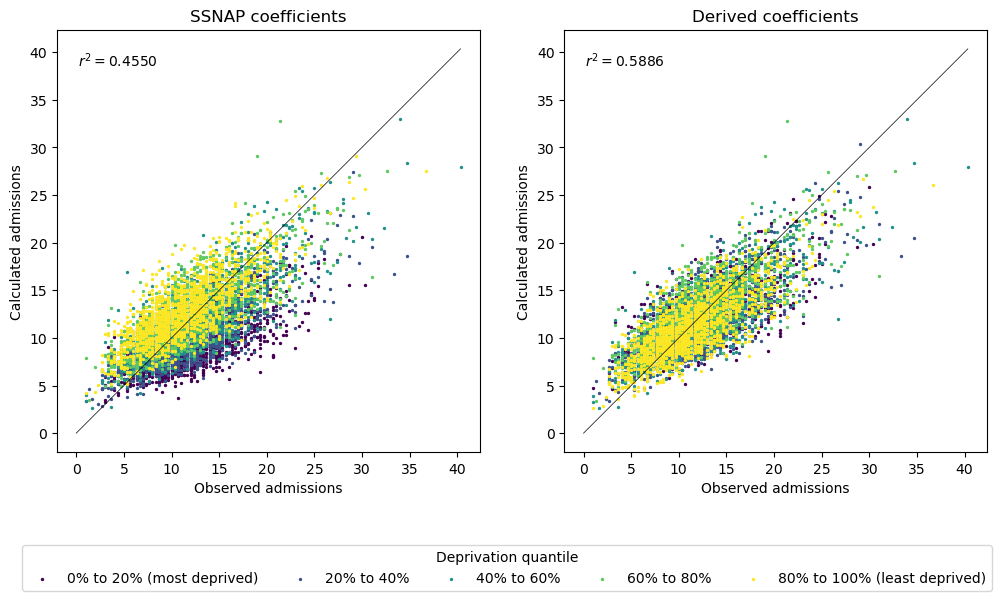

In [85]:
# fig, axs = plt.subplots(1, 4, figsize=(12, 4))
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Equal line:
for ax in axs[:2]:
    ax.plot([0, ad_max], [0, ad_max], color='k', linewidth=0.5)
# axs[2].plot([-diff_max, diff_max], [-diff_max, diff_max], color='k', linewidth=0.5)
# axs[2].axvline(0.0, color='k', linewidth=0.5)
# axs[2].axhline(0.0, color='k', linewidth=0.5)

for q, q0 in enumerate(qmin_list):
    mask = df_stats['depriv_quantile_min'] == q0
    df_here = df_stats.filter(mask)
    kwargs = dict(color=colours[q], s=2, alpha=1.0, label=legend_labels[q0])
    axs[0].scatter(df_here['admissions'], df_here['admissions_predicted_ssnap'], **kwargs)
    axs[1].scatter(df_here['admissions'], df_here['admissions_predicted_depriv'], **kwargs)
    # axs[2].scatter(
    #     df_here['admissions_predicted_ssnap'] - df_here['admissions'],
    #     df_here['admissions_predicted_depriv'] - df_here['admissions'],
    #     **kwargs
    # )
    # axs[2].scatter(
    #     df_here['admissions'], df_here['admissions_predicted_ssnap'] - df_here['admissions'],
    #     **kwargs
    # )
        
    # axs[3].scatter(
    #     df_here['admissions'], df_here['admissions_predicted_depriv'] - df_here['admissions'],
    #     **kwargs
    # )

    # for i in range(len(df_here)):
    #     axs[2].plot(
    #         [df_here['admissions'][i], df_here['admissions'][i]],
    #         [df_here['admissions_predicted_ssnap'][i] - df_here['admissions'][i],
    #          df_here['admissions_predicted_depriv'][i] - df_here['admissions'][i]],
    #         marker='o', markerfacecolor=colours[q], color='k', linewidth=0.5, markersize=1,
    #     )
    
    # axs[3].scatter(
    #     df_here['admissions'], 
    #     (df_here['admissions_predicted_ssnap'] - df_here['admissions_predicted_depriv']),
    #     **kwargs
    # )


axs[0].legend(bbox_to_anchor=[0.5, -0.0], loc='upper center', title='Deprivation quantile', bbox_transform=fig.transFigure, ncol=5)
    
for ax in axs[:2]:
    ax.set_xlabel('Observed admissions')
    ax.set_ylabel('Calculated admissions')
    ax.set_aspect('equal')

axs[0].set_title('SSNAP coefficients')
axs[1].set_title('Derived coefficients')

# axs[2].set_xlabel('Difference between\nadmissions from SSNAP coefficients\nand observed admissions')
# axs[2].set_ylabel('Difference between\nadmissions from derived coefficients\nand observed admissions')

axs[0].annotate(r'$r^2=$' + f"{dict_r2_ssnap['r2_all']:.4f}", xy=(0.05, 0.95), ha='left', va='top', xycoords='axes fraction')
axs[1].annotate(r'$r^2=$' + f"{dict_r2['r2_all']:.4f}", xy=(0.05, 0.95), ha='left', va='top', xycoords='axes fraction')

# plt.savefig('admissions_prediction_comparison.png', bbox_inches='tight')
plt.show()